# Global Fetch QA: Geographic Bias, Visual Spot-Check, and Failed-Tile Inspection

Set `MODE` in the setup cell to choose which dataset part to audit. It defaults to `"sectors"`, the 28 cells the paper evaluates on; `"substations"` audits the full unsampled substation extraction instead.

Three checks on the full multi-continent fetch before treating it as final for
the peer-reviewed dataset.

**Check 1 — Geographic distribution of kept tiles.**
Plot all surviving tiles globally and look at per-latitude yield. If yield rises
with absolute latitude (low near the equator, high in temperate zones), the loss
is cloud-driven and defensible as a documented bias. If yield is uniformly low
or scattered randomly, the loss came from something else (network, API errors,
fetcher quirks) and warrants investigation.

**Check 2 — Visual spot-check of random surviving tiles.**
Sample N random kept tiles globally (or per region), render the S2 RGB
composite, and confirm they look like substations and aren't garbage that
slipped through QC.

**Check 3 — Failed-tile inspection.**
Anti-join the deduped attempted assets against `summary.csv` to find every
asset that was attempted but never produced a final tile. Map them, look at
their distribution, and export their coordinates so a few can be re-fetched
manually to diagnose the failure mode.

> **What "failed" means here.** Without per-region fetch/QC logs, a missing
> tile could be (a) a fetch failure (no usable STAC scene, network drop, API
> error) or (b) a QC rejection (too few valid pixels, edge artifact, out of
> value range). This notebook lumps both together as "failed" because they're
> indistinguishable from what `summary.csv` and the deduped parquets alone can
> tell us. The geographic pattern of failures is usually enough to distinguish:
> heavy concentration in cloudy bands → QC; scattered with no spatial pattern →
> network/API.

## Dataset structure (assumed)

```
data/curated_datasets/dataset_<region>_stac_v1/
├── _SUCCESS
├── manifest.json
├── summary.csv
└── images/
    └── {asset_id}_stac_{modality_combo}.npy

data/PIPELINE/02-deduped-assets/
└── <region>_deduped_assets_substations[_sampled].parquet
```

Adjust `REGIONS`, `DEDUPED_DIR`, and `DATASETS_DIR` in the setup cell if needed.


## Setup


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import sys
from pathlib import Path

# =============================================================================
# WHICH DATASET TO AUDIT
# =============================================================================
#   "sectors"     part B, the 28 cells the paper evaluates on. attempted =
#                 the per-cell sample list, kept = the fetched v1 cell (before
#                 the 1k cap, so the yield here is the fetch yield).
#   "substations" part A, the full unsampled substation extraction.
#
# this notebook originally only covered part A, which meant the geographic
# bias check had never been run against the data the paper actually uses.
MODE = "sectors"

V1_REGIONS = ["africa", "asia", "australia-oceania", "central-america",
              "europe", "north-america", "south-america"]
V1_SECTORS = ["energy", "water", "transport", "telecom"]

# walk up from the notebook's directory until the curation package appears,
# so the paths hold wherever this notebook is opened from
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "curation" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from curation.paths import DEDUPED_DIR, SAMPLES_DIR
from curation.paths import CURATED_DIR as DATASETS_DIR

if MODE == "sectors":
    # key -> (dataset dir under curated_datasets, attempted-list filename)
    ATTEMPTED_DIR = SAMPLES_DIR
    REGIONS = {
        f"{region}/{sector}": (f"dataset_{region}_{sector}_v1",
                               f"{region}_{sector}_v1_sample.parquet")
        for region in V1_REGIONS for sector in V1_SECTORS
    }
elif MODE == "substations":
    ATTEMPTED_DIR = DEDUPED_DIR
    _SAMPLED = {"europe", "north-america"}
    REGIONS = {
        region: (f"dataset_{region}_stac_v1",
                 f"{region}_deduped_assets_substations"
                 f"{'_sampled' if region in _SAMPLED else ''}.parquet")
        for region in V1_REGIONS
    }
else:
    raise ValueError(f"MODE must be 'sectors' or 'substations', got {MODE!r}")

# the loader below reads from DEDUPED_DIR by name; point it at whichever
# source this mode uses
DEDUPED_DIR = ATTEMPTED_DIR

print(f"MODE={MODE}: auditing {len(REGIONS)} cells")
print(f"  attempted lists: {ATTEMPTED_DIR}")
print(f"  fetched tiles  : {DATASETS_DIR}")

# asset-id column name in the attempted parquets. falls back to alternatives.
ASSET_ID_CANDIDATES = ("asset_id", "id", "osm_id")
LAT_CANDIDATES      = ("lat", "latitude", "centroid_y")
LON_CANDIDATES      = ("lon", "longitude", "centroid_x")


def first_present(df, candidates):
    return next((c for c in candidates if c in df.columns), None)


In [ ]:
# load each cell's attempted list and its kept tiles (summary.csv).
# tag each row with its cell key so we can analyse per-cell or pooled.

attempted_frames = []
kept_frames      = []
region_stats     = []
region_paths     = {}  # region -> {"dataset_dir": Path, "images_dir": Path, "summary": Path}

for region, entry in REGIONS.items():
    if entry is None:
        continue
    dataset_subdir, deduped_file = entry

    deduped_path = DEDUPED_DIR / deduped_file
    dataset_dir  = DATASETS_DIR / dataset_subdir
    summary_path = dataset_dir / "summary.csv"
    images_dir   = dataset_dir / "images"

    if not deduped_path.exists():
        print(f"⚠️  {region}: missing deduped file at {deduped_path}")
        continue
    if not summary_path.exists():
        print(f"⚠️  {region}: missing summary.csv at {summary_path}")
        continue

    attempted = pd.read_parquet(deduped_path)
    kept      = pd.read_csv(summary_path)

    lat_col = first_present(attempted, LAT_CANDIDATES)
    lon_col = first_present(attempted, LON_CANDIDATES)
    aid_col = first_present(attempted, ASSET_ID_CANDIDATES)
    if lat_col is None or lon_col is None:
        print(f"⚠️  {region}: couldn't find lat/lon in {list(attempted.columns)}")
        continue
    if aid_col is None:
        print(f"⚠️  {region}: couldn't find asset_id in {list(attempted.columns)} "
              f"— failed-tile join will be skipped for this region")

    keep_cols_attempted = {lat_col: "lat", lon_col: "lon"}
    if aid_col is not None:
        keep_cols_attempted[aid_col] = "asset_id"
    att = attempted[list(keep_cols_attempted)].rename(columns=keep_cols_attempted).copy()
    att["region"] = region

    k = kept[["asset_id", "lat", "lon"]].copy() if "asset_id" in kept.columns \
        else kept[["lat", "lon"]].copy()
    k["region"] = region

    attempted_frames.append(att)
    kept_frames.append(k)
    region_stats.append({
        "region":    region,
        "attempted": len(att),
        "kept":      len(k),
        "yield_pct": len(k) / len(att) * 100 if len(att) else float("nan"),
    })
    region_paths[region] = {
        "dataset_dir": dataset_dir,
        "summary":     summary_path,
        "images_dir":  images_dir,
    }

if not attempted_frames:
    raise RuntimeError("No regions loaded — check your paths.")

attempted_all = pd.concat(attempted_frames, ignore_index=True)
kept_all      = pd.concat(kept_frames, ignore_index=True)
region_stats  = pd.DataFrame(region_stats)

print(region_stats.to_string(index=False))
print()
print(f"Total attempted: {len(attempted_all):,}")
print(f"Total kept:      {len(kept_all):,}")
print(f"Overall yield:   {len(kept_all) / len(attempted_all) * 100:.1f}%")

## Check 1 — Geographic distribution

Three views:
1. World scatter of attempted (gray) vs kept (red), with per-region coloring optional
2. Per-cell yield heatmap on a 5° grid
3. Yield by latitude band — the cleanest cloud-cover signal


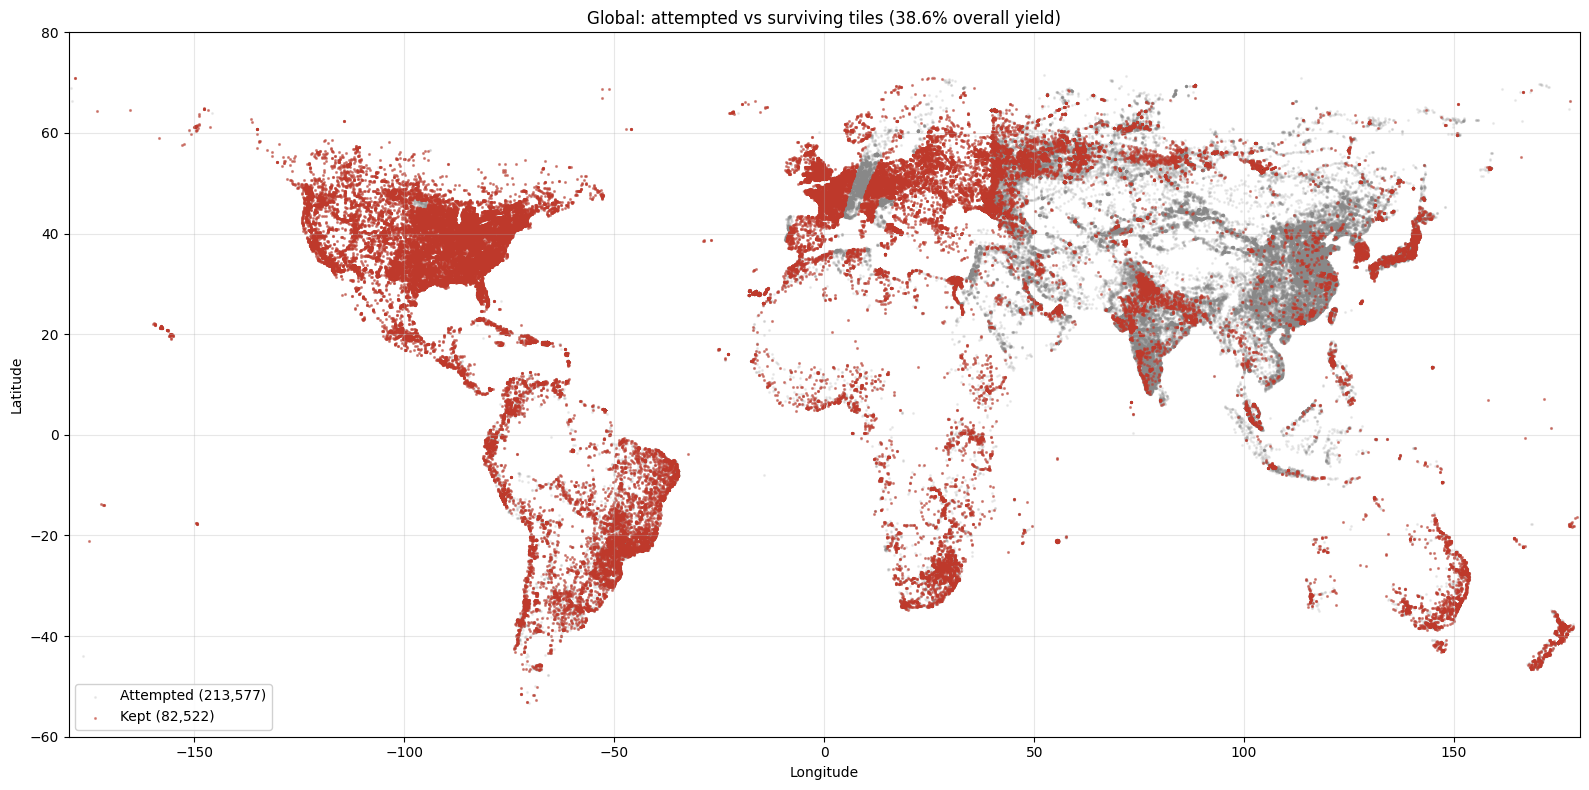

In [4]:
# 1a. world scatter — attempted (gray) underneath, kept (red) on top.
fig, ax = plt.subplots(figsize=(16, 8))
ax.scatter(attempted_all["lon"], attempted_all["lat"],
           s=1.5, alpha=0.12, color="#888888",
           label=f"Attempted ({len(attempted_all):,})")
ax.scatter(kept_all["lon"], kept_all["lat"],
           s=1.5, alpha=0.45, color="#c0392b",
           label=f"Kept ({len(kept_all):,})")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Global: attempted vs surviving tiles "
             f"({len(kept_all)/len(attempted_all)*100:.1f}% overall yield)")
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


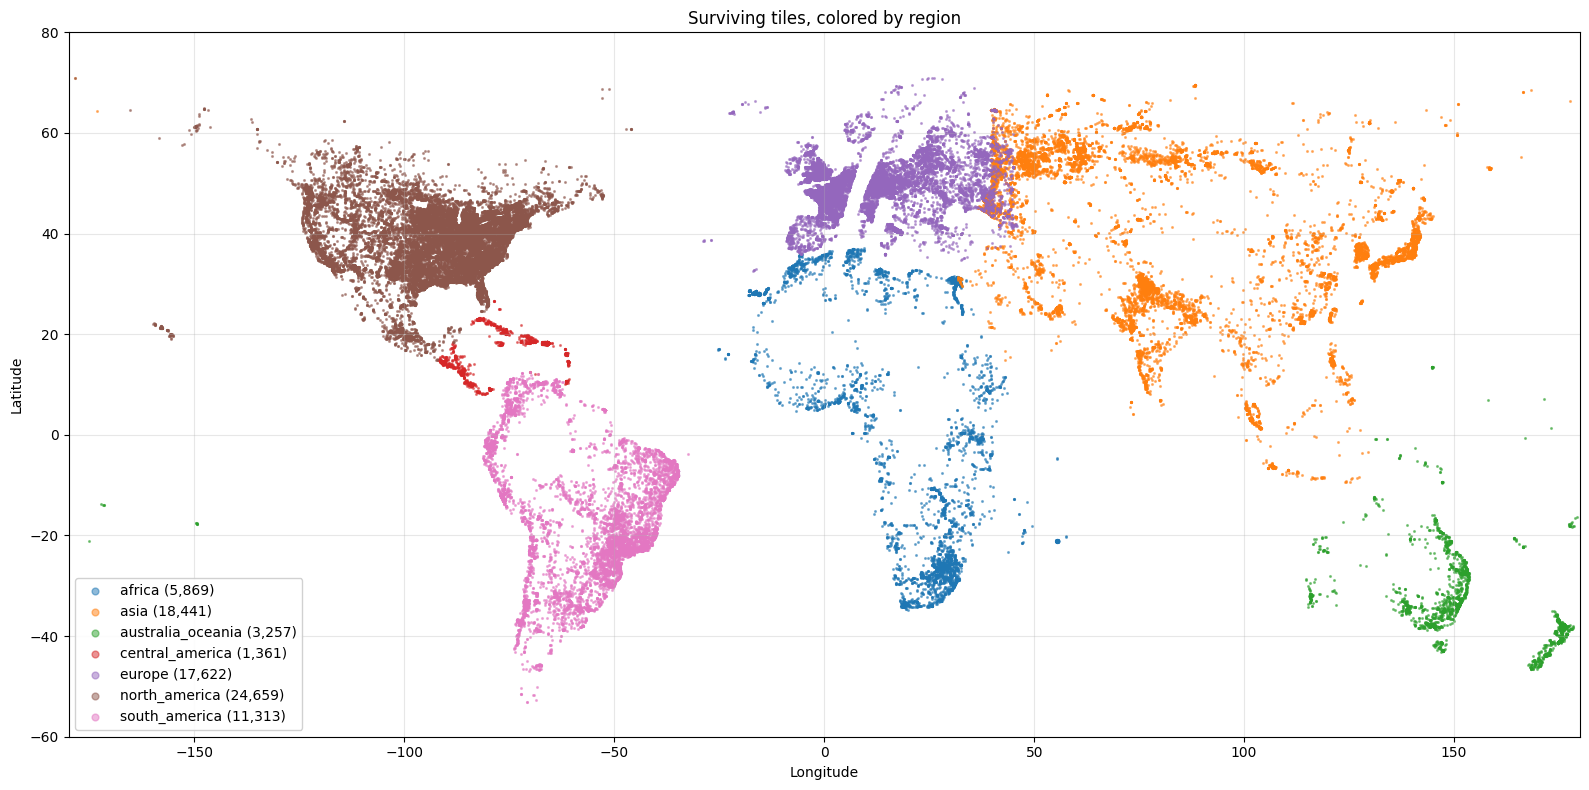

In [5]:
# 1b. same scatter, but colored by region (kept tiles only) — useful sanity check
#     that no region is over/under-represented after sampling.
fig, ax = plt.subplots(figsize=(16, 8))
cmap = plt.get_cmap("tab10")
for i, region in enumerate(sorted(kept_all["region"].unique())):
    sub = kept_all[kept_all["region"] == region]
    ax.scatter(sub["lon"], sub["lat"], s=1.5, alpha=0.5,
               color=cmap(i % 10), label=f"{region} ({len(sub):,})")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Surviving tiles, colored by region")
ax.legend(loc="lower left", framealpha=0.9, markerscale=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


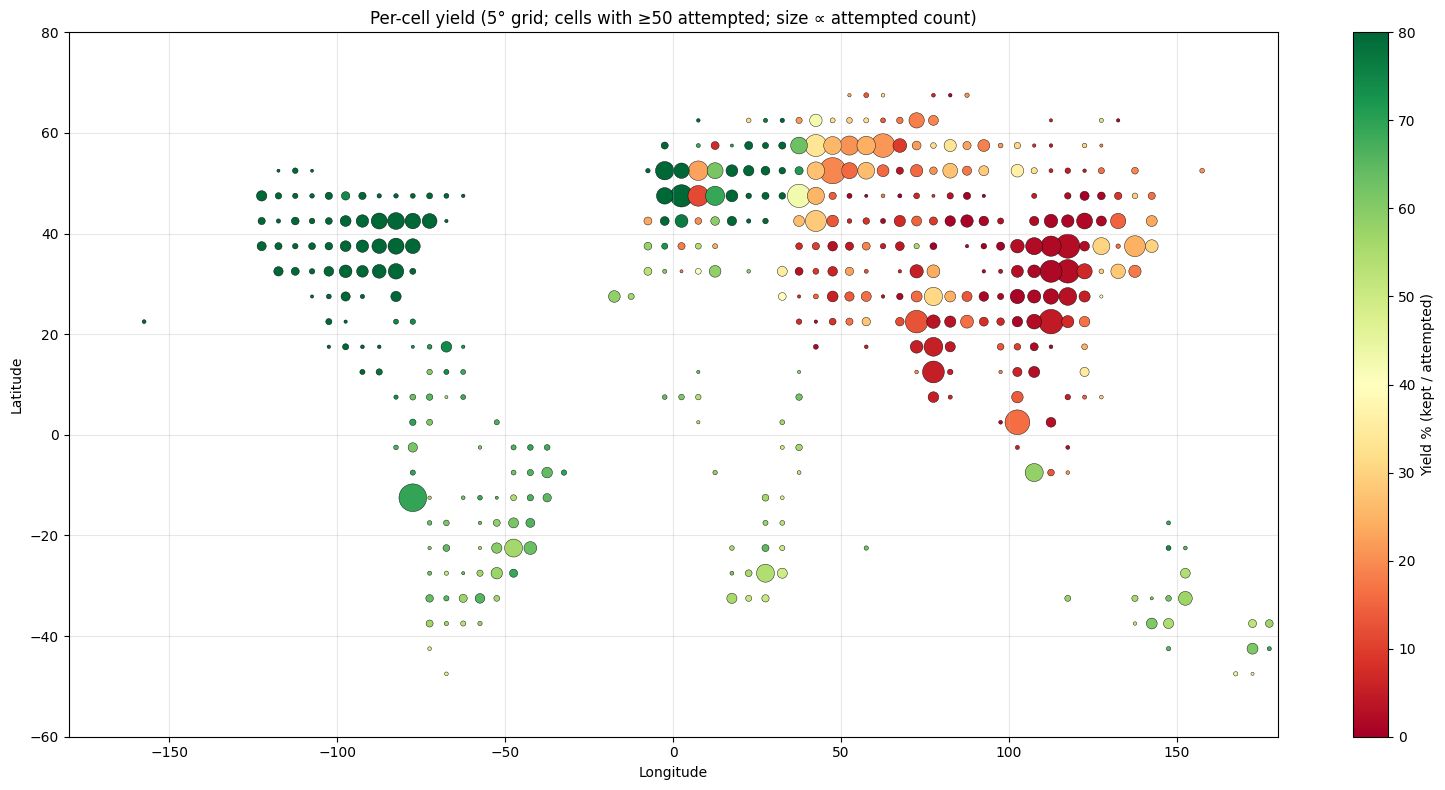

In [6]:
# 2. per-cell yield on a 5° grid (global).
BIN_DEG = 5

att_cells = pd.DataFrame({
    "lat_bin": (attempted_all["lat"] // BIN_DEG * BIN_DEG).astype(int),
    "lon_bin": (attempted_all["lon"] // BIN_DEG * BIN_DEG).astype(int),
})
fin_cells = pd.DataFrame({
    "lat_bin": (kept_all["lat"] // BIN_DEG * BIN_DEG).astype(int),
    "lon_bin": (kept_all["lon"] // BIN_DEG * BIN_DEG).astype(int),
})

att_counts = att_cells.value_counts().rename("attempted").reset_index()
fin_counts = fin_cells.value_counts().rename("kept").reset_index()

yield_df = att_counts.merge(fin_counts, on=["lat_bin", "lon_bin"], how="left")
yield_df["kept"] = yield_df["kept"].fillna(0).astype(int)
yield_df["yield_pct"] = yield_df["kept"] / yield_df["attempted"] * 100
yield_df = yield_df[yield_df["attempted"] >= 50]   # filter noisy cells

print("Highest-yield cells (≥50 attempted):")
print(yield_df.nlargest(10, "yield_pct").to_string(index=False))
print("\nLowest-yield cells (≥50 attempted):")
print(yield_df.nsmallest(10, "yield_pct").to_string(index=False))

fig, ax = plt.subplots(figsize=(16, 8))
sc = ax.scatter(
    yield_df["lon_bin"] + BIN_DEG / 2,
    yield_df["lat_bin"] + BIN_DEG / 2,
    c=yield_df["yield_pct"],
    s=yield_df["attempted"] / 10,
    cmap="RdYlGn",
    vmin=0, vmax=80,
    edgecolor="black", linewidth=0.3,
)
plt.colorbar(sc, ax=ax, label="Yield % (kept / attempted)")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Per-cell yield ({BIN_DEG}° grid; cells with ≥50 attempted; "
             f"size ∝ attempted count)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


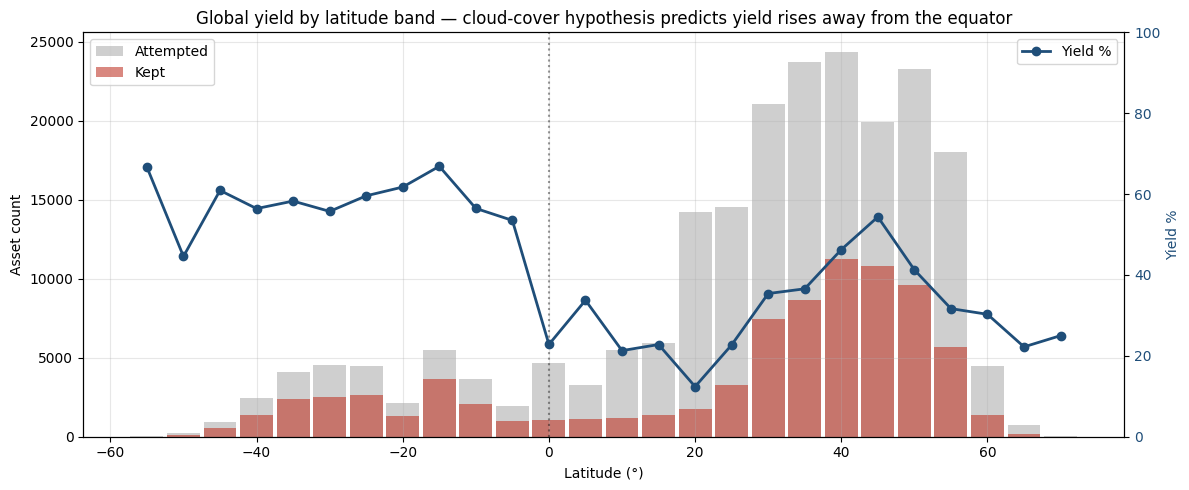

In [7]:
# 3. yield by latitude band — the cloud-cover litmus test, globally.
att_by_lat = att_cells.groupby("lat_bin").size().rename("attempted")
fin_by_lat = fin_cells.groupby("lat_bin").size().rename("kept")
lat_df = pd.concat([att_by_lat, fin_by_lat], axis=1).fillna(0).astype(int)
lat_df["yield_pct"] = lat_df["kept"] / lat_df["attempted"] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(lat_df.index, lat_df["attempted"], width=BIN_DEG * 0.9,
        color="#888888", alpha=0.4, label="Attempted")
ax1.bar(lat_df.index, lat_df["kept"], width=BIN_DEG * 0.9,
        color="#c0392b", alpha=0.6, label="Kept")
ax1.set_xlabel("Latitude (°)")
ax1.set_ylabel("Asset count")
ax1.axvline(0, color="black", linestyle=":", alpha=0.4)  # equator
ax1.legend(loc="upper left")

ax2.plot(lat_df.index, lat_df["yield_pct"], "o-",
         color="#1f4e79", linewidth=2, label="Yield %")
ax2.set_ylabel("Yield %", color="#1f4e79")
ax2.tick_params(axis="y", labelcolor="#1f4e79")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right")

ax1.set_title("Global yield by latitude band — cloud-cover hypothesis predicts "
              "yield rises away from the equator")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nYield by latitude band (full table):")
print(lat_df.to_string())


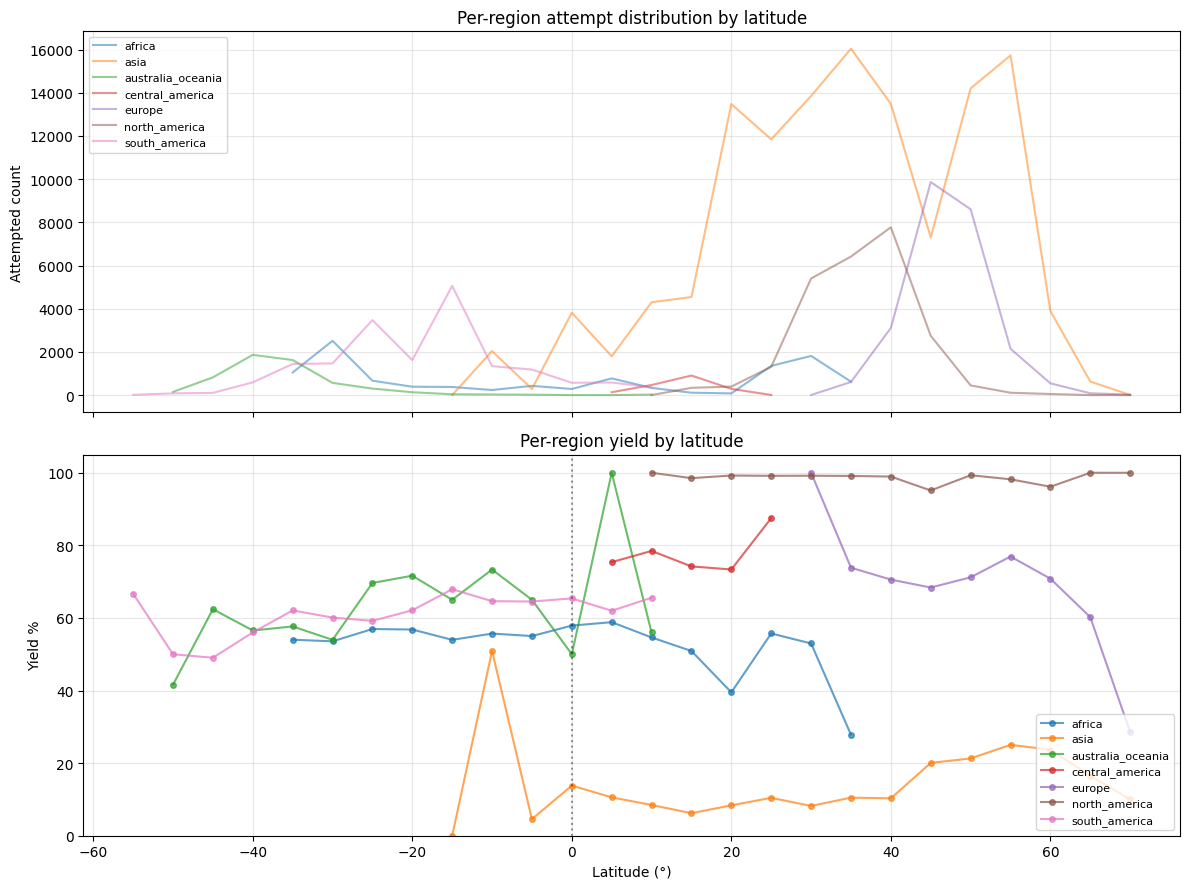

In [8]:
# per-region yield-by-latitude — to see if some regions show the cloud signal
# clearly while others don't (e.g. asia tropical vs. north-america temperate).
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1, ax2 = axes

cmap = plt.get_cmap("tab10")
for i, region in enumerate(sorted(attempted_all["region"].unique())):
    att_r = attempted_all[attempted_all["region"] == region]
    kept_r = kept_all[kept_all["region"] == region]

    att_lat = (att_r["lat"] // BIN_DEG * BIN_DEG).astype(int).value_counts().sort_index()
    kept_lat = (kept_r["lat"] // BIN_DEG * BIN_DEG).astype(int).value_counts().sort_index()
    yld = (kept_lat / att_lat * 100).reindex(att_lat.index).fillna(0)

    ax1.plot(att_lat.index, att_lat.values, "-", color=cmap(i % 10),
             alpha=0.5, label=region)
    ax2.plot(yld.index, yld.values, "o-", color=cmap(i % 10),
             alpha=0.7, label=region, markersize=4)

ax1.set_ylabel("Attempted count")
ax1.set_title("Per-region attempt distribution by latitude")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.3)

ax2.set_xlabel("Latitude (°)")
ax2.set_ylabel("Yield %")
ax2.set_ylim(0, 105)
ax2.axvline(0, color="black", linestyle=":", alpha=0.4)
ax2.set_title("Per-region yield by latitude")
ax2.legend(loc="lower right", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Interpreting Check 1

The latitude-band plot is the cleanest test.

- **Yield rises with absolute latitude (low in 0–20°, high in 30°+):**
  cloud-cover-driven loss confirmed. Defensible to disclose as a documented bias.

- **Yield is uniformly low across all latitudes:**
  not cloud-driven. Worth investigating before publishing — could be network,
  API errors, or something in the fetcher itself.

- **Yield differs sharply *between* regions at similar latitudes:**
  points at a per-region fetch issue (network, run conditions, parquet sampling
  ratio). The per-region overlay in the second plot is the place to spot this.

- **Yield is uniformly moderate or high:**
  the loss is below the regions where you'd worry. The headline yield number
  is mostly an artifact of the attempted denominator.


## Check 2 — Visual spot-check of random tiles

Sample N tiles either globally (default) or restricted to a single region,
render the S2 RGB composite (B04, B03, B02 — first 3 channels), and inspect.


In [9]:
# knobs for the spot-check
N_SAMPLES     = 30
REGION_FILTER = None     # None = sample globally; or set to e.g. "asia"
RANDOM_SEED   = 42


def resolve_image_path(region, image_file_value):
    """Resolve summary.csv's image_file value to an actual on-disk path."""
    images_dir  = region_paths[region]["images_dir"]
    dataset_dir = region_paths[region]["dataset_dir"]
    p = Path(str(image_file_value))
    if p.is_absolute() and p.exists():
        return p
    candidate = images_dir / p.name
    if candidate.exists():
        return candidate
    candidate = dataset_dir / p
    if candidate.exists():
        return candidate
    return None


def load_tile_image(region, image_file_value):
    path = resolve_image_path(region, image_file_value)
    if path is None:
        return None
    return np.load(path)


In [ ]:
# re-read each kept region's summary.csv with full columns (we only kept lat/lon
# for the pooled DataFrame above; we need image_file etc. for plotting).
summaries_full = {}
for region in region_paths:
    summaries_full[region] = pd.read_csv(region_paths[region]["summary"])
    summaries_full[region]["region"] = region

# build sampling pool
if REGION_FILTER is not None:
    if REGION_FILTER not in summaries_full:
        raise KeyError(f"REGION_FILTER={REGION_FILTER!r} not in loaded regions "
                       f"({list(summaries_full)})")
    pool = summaries_full[REGION_FILTER]
    pool_label = REGION_FILTER
else:
    pool = pd.concat(summaries_full.values(), ignore_index=True)
    pool_label = "global"

sample = pool.sample(n=min(N_SAMPLES, len(pool)), random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Sampling {len(sample)} tiles from pool ({pool_label}, n={len(pool):,})")


In [ ]:
# load all sampled tiles
loaded = []
for _, row in sample.iterrows():
    img = load_tile_image(row["region"], row["image_file"])
    loaded.append((row, img))

n_loaded = sum(1 for _, img in loaded if img is not None)
print(f"Loaded {n_loaded}/{len(loaded)} sample tiles.")


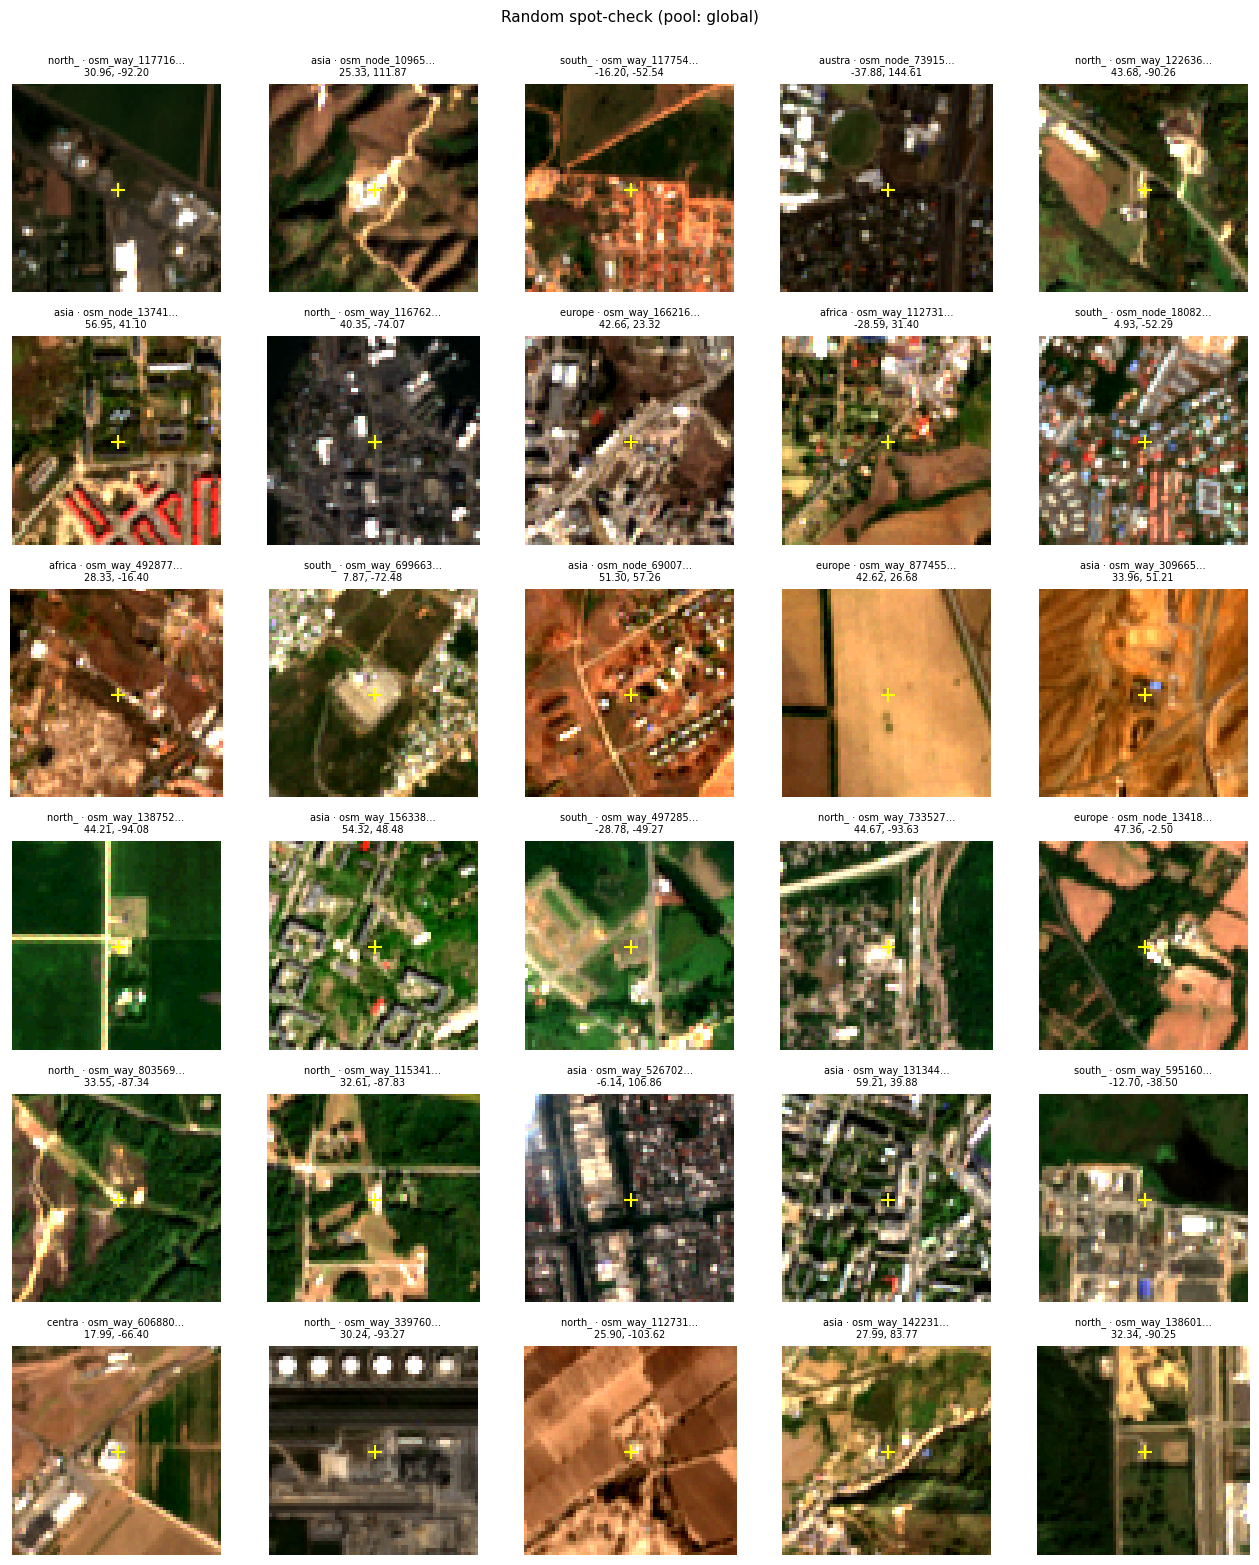

In [12]:
def rgb_from_tile(image, low_pct=2, high_pct=98):
    """
    Build an RGB composite from a (C, H, W) S2-first multimodal tile.
    Band order for sentinel2_ms is [B04, B03, B02, B08, B11, B12, B8A], so
    RGB = channels [0, 1, 2]. Applies a percentile contrast stretch.
    """
    if image is None or image.shape[0] < 3:
        return None
    rgb = image[:3].astype(np.float32)
    rgb = np.transpose(rgb, (1, 2, 0))
    nonzero = rgb[rgb > 0]
    if nonzero.size == 0:
        return np.zeros_like(rgb, dtype=np.uint8)
    lo, hi = np.percentile(nonzero, [low_pct, high_pct])
    rgb = np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)
    return (rgb * 255).astype(np.uint8)


# auto-pick a grid shape
n = len(loaded)
cols = 5
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6))
axes = np.atleast_2d(axes).flatten()

for ax, (row, image) in zip(axes, loaded):
    rgb = rgb_from_tile(image)
    if rgb is None:
        ax.text(0.5, 0.5, "no image", ha="center", va="center",
                transform=ax.transAxes)
    else:
        ax.imshow(rgb)
        h, w = rgb.shape[:2]
        ax.plot(w / 2, h / 2, "+", color="yellow", markersize=10, mew=1.5)
    title = f"{row['region'][:6]} · {str(row['asset_id'])[:14]}…\n{row['lat']:.2f}, {row['lon']:.2f}"
    ax.set_title(title, fontsize=7)
    ax.axis("off")

for ax in axes[len(loaded):]:
    ax.axis("off")

plt.suptitle(f"Random spot-check (pool: {pool_label})", y=1.0, fontsize=11)
plt.tight_layout()
plt.show()


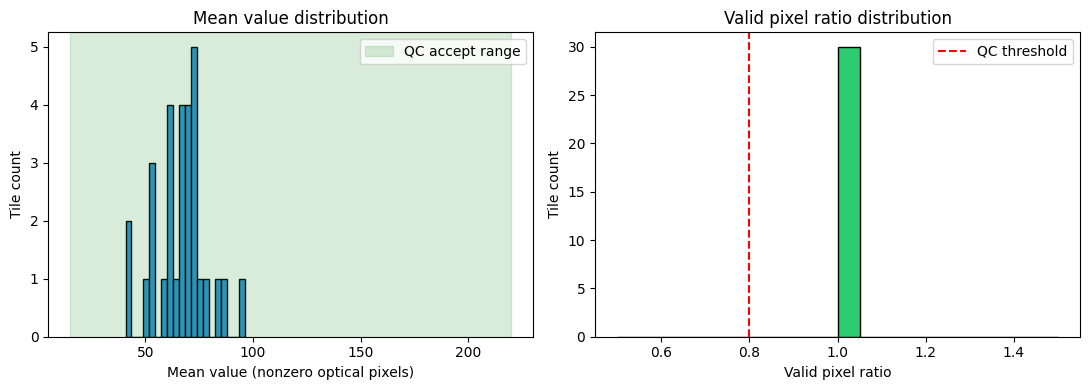

In [13]:
# numeric distributions for the sample, to surface tiles that just barely passed QC
stats = []
for row, img in loaded:
    if img is None:
        continue
    optical = img[:7]   # S2 7 bands
    nz = optical[optical > 0]
    if nz.size == 0:
        stats.append({"asset_id": row["asset_id"], "region": row["region"],
                      "mean": 0.0, "valid_ratio": 0.0})
        continue
    valid_mask = np.any(optical != 0, axis=0)
    stats.append({
        "asset_id":    row["asset_id"],
        "region":      row["region"],
        "mean":        float(nz.mean()),
        "valid_ratio": float(valid_mask.mean()),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(stats_df["mean"], bins=20, color="#3498db", edgecolor="black")
ax1.axvspan(15, 220, alpha=0.15, color="green", label="QC accept range")
ax1.set_xlabel("Mean value (nonzero optical pixels)")
ax1.set_ylabel("Tile count")
ax1.set_title("Mean value distribution")
ax1.legend()

ax2.hist(stats_df["valid_ratio"], bins=20, color="#2ecc71", edgecolor="black")
ax2.axvline(0.80, color="red", linestyle="--", label="QC threshold")
ax2.set_xlabel("Valid pixel ratio")
ax2.set_ylabel("Tile count")
ax2.set_title("Valid pixel ratio distribution")
ax2.legend()

plt.tight_layout()
plt.show()


### Interpreting Check 2

The yellow `+` marks where the substation centroid should be.

- **Most tiles show recognizable substation infrastructure near the centroid**
  (regular geometric patterns, transmission line connections, cleared land):
  the tiles are good.

- **Tiles look like generic land cover with no obvious infrastructure at the +:**
  partially expected — substations are small relative to a 600m × 600m tile (300m
  buffer × 2). At 10m S2 resolution, a substation might be 10–30 pixels in a
  60-pixel tile. You should still see a centered geometric feature in most
  tiles. If you don't, OSM substation centroids may be noisy.

- **Multiple tiles look corrupted (heavy striping, blocks of solid color,
  obvious clouds despite the <20% threshold):** real data quality issue.
  Worth investigating — check whether `eo:cloud_cover` metadata is being
  respected, and whether windowed reads are landing in scene gaps.

To zoom into a single region, set `REGION_FILTER = "asia"` (or any other
region name) in the knobs cell and re-run from there.


## Check 3 — Failed-tile inspection

Anti-join the deduped attempted assets against `summary.csv` to find every
asset that was attempted but never produced a final tile. As noted up top,
this conflates fetch failures and QC rejections — but the *geographic pattern*
of failures usually tells the story.

What we'll do:
1. Build the failed set per region (and pooled).
2. Map failures vs survivors to see if they cluster anywhere.
3. Export failure coordinates to CSV so you can re-fetch a few manually
   (or paste into Google Earth / a STAC explorer).
4. Cross-reference failures with the latitude-band yield from Check 1.


In [ ]:
# build per-region failed sets via anti-join on asset_id.
# requires asset_id in both the deduped parquet and summary.csv.
failed_frames = []
failed_stats  = []

for region in region_paths:
    att_r = attempted_all[attempted_all["region"] == region]
    if "asset_id" not in att_r.columns or att_r["asset_id"].isna().all():
        print(f"⚠️  {region}: no asset_id in attempted, skipping anti-join")
        continue
    kept_r = kept_all[kept_all["region"] == region]
    if "asset_id" not in kept_r.columns:
        print(f"⚠️  {region}: no asset_id in kept, skipping anti-join")
        continue

    kept_ids = set(kept_r["asset_id"].astype(str))
    fail_mask = ~att_r["asset_id"].astype(str).isin(kept_ids)
    failed = att_r[fail_mask].copy()

    failed_frames.append(failed)
    failed_stats.append({
        "region":     region,
        "attempted":  len(att_r),
        "kept":       len(kept_r),
        "failed":     len(failed),
        "fail_pct":   len(failed) / len(att_r) * 100 if len(att_r) else float("nan"),
    })

failed_stats = pd.DataFrame(failed_stats)
print(failed_stats.to_string(index=False))

if failed_frames:
    failed_all = pd.concat(failed_frames, ignore_index=True)
    print(f"\nTotal failed (attempted - kept): {len(failed_all):,}")
else:
    failed_all = pd.DataFrame(columns=["asset_id", "lat", "lon", "region"])
    print("\nNo failed sets built — check that asset_id is present in both files.")


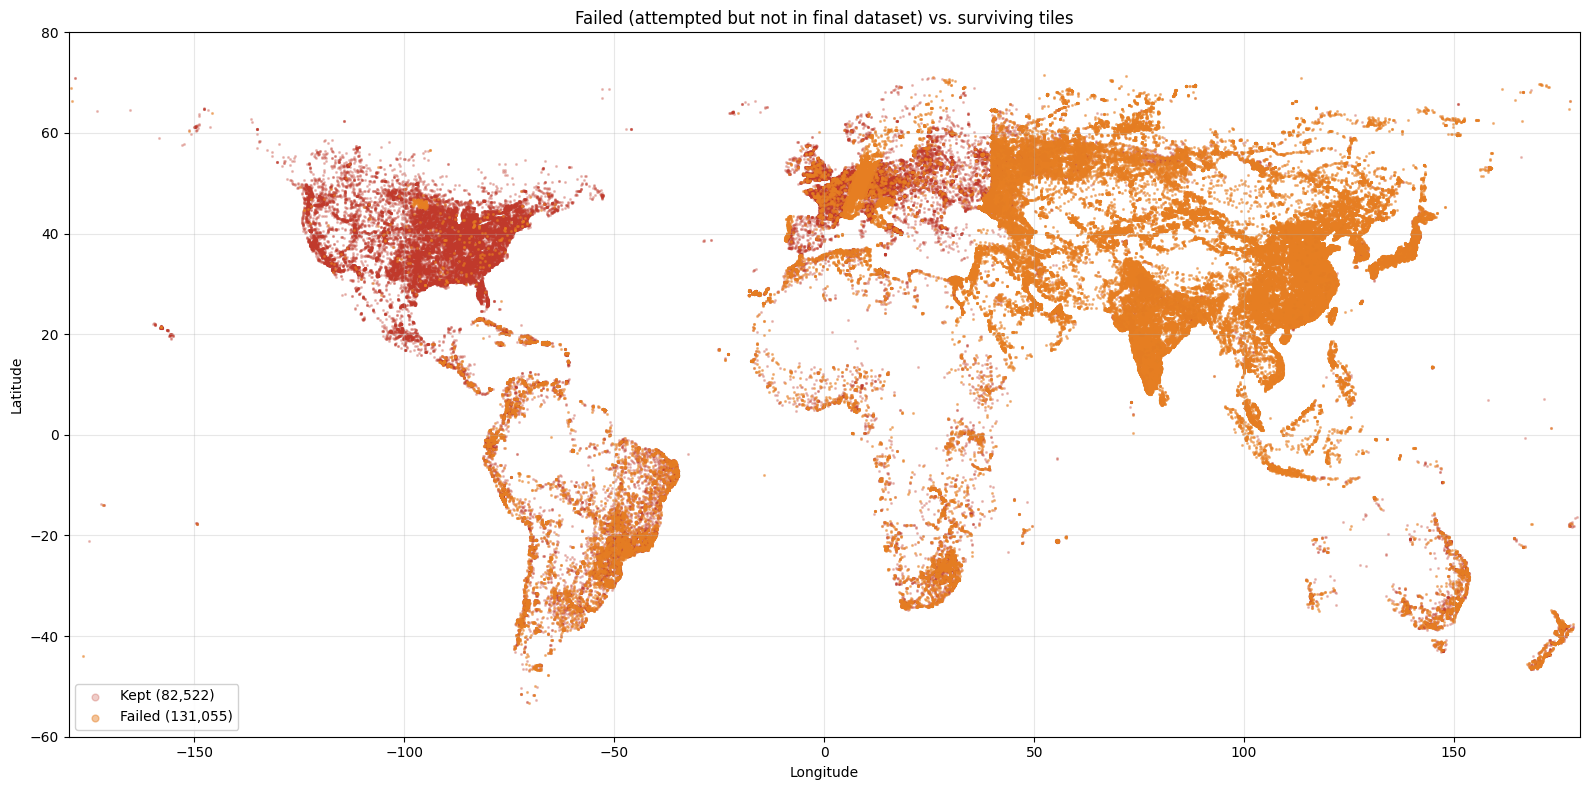

In [15]:
# map: survivors (faint red) vs failures (orange).
if len(failed_all) == 0:
    print("Skipping map — no failures available.")
else:
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.scatter(kept_all["lon"], kept_all["lat"],
               s=1.5, alpha=0.25, color="#c0392b",
               label=f"Kept ({len(kept_all):,})")
    ax.scatter(failed_all["lon"], failed_all["lat"],
               s=1.5, alpha=0.45, color="#e67e22",
               label=f"Failed ({len(failed_all):,})")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 80)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Failed (attempted but not in final dataset) vs. surviving tiles")
    ax.legend(loc="lower left", framealpha=0.9, markerscale=4)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


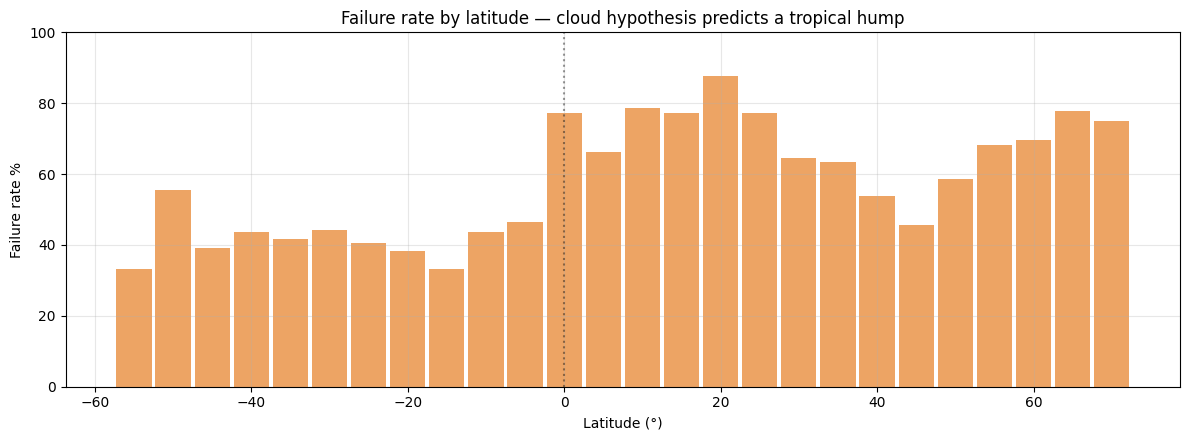

In [16]:
# failure rate by latitude band — if clouds are the cause, this should mirror
# the inverse of the kept-yield plot from Check 1.
if len(failed_all) == 0:
    print("Skipping latitude analysis — no failures available.")
else:
    failed_cells = pd.DataFrame({
        "lat_bin": (failed_all["lat"] // BIN_DEG * BIN_DEG).astype(int),
    })
    failed_by_lat = failed_cells.groupby("lat_bin").size().rename("failed")
    fail_lat_df = pd.concat([att_by_lat, failed_by_lat], axis=1).fillna(0).astype(int)
    fail_lat_df["fail_pct"] = fail_lat_df["failed"] / fail_lat_df["attempted"] * 100

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(fail_lat_df.index, fail_lat_df["fail_pct"], width=BIN_DEG * 0.9,
           color="#e67e22", alpha=0.7)
    ax.axvline(0, color="black", linestyle=":", alpha=0.4)
    ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Failure rate %")
    ax.set_ylim(0, 100)
    ax.set_title("Failure rate by latitude — cloud hypothesis predicts a tropical hump")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# export failure coordinates so you can re-fetch a few manually for diagnosis.
# two outputs:
#   (a) full CSV of every failure (asset_id, lat, lon, region) — for the record
#   (b) a small stratified sample suitable for hand inspection in a STAC
#       explorer or Google Earth (Planet Explorer URL provided per row)

OUT_DIR = Path("./qa_outputs")
OUT_DIR.mkdir(exist_ok=True)

if len(failed_all) == 0:
    print("Skipping export — no failures available.")
else:
    full_path = OUT_DIR / "failed_tiles_all.csv"
    failed_all.to_csv(full_path, index=False)
    print(f"✓ Wrote {len(failed_all):,} rows → {full_path}")

    # stratified sample: up to N per region
    N_PER_REGION = 10
    sampled = (
        failed_all.groupby("region", group_keys=False)
        .apply(lambda g: g.sample(n=min(N_PER_REGION, len(g)), random_state=0))
        .reset_index(drop=True)
    )

    # Planetary Computer Explorer URL — drops you on a map at the point.
    # adjust collection / date range if you want to inspect specific scenes.
    def pc_url(lat, lon):
        return (
            "https://planetarycomputer.microsoft.com/explore"
            f"?c={lon:.4f},{lat:.4f}&z=14&v=2"
            "&d=sentinel-2-l2a&m=Most+recent+(low+cloud)"
        )

    sampled["pc_explorer_url"] = [pc_url(r.lat, r.lon) for r in sampled.itertuples()]
    sample_path = OUT_DIR / "failed_tiles_sample_for_inspection.csv"
    sampled.to_csv(sample_path, index=False)
    print(f"✓ Wrote {len(sampled):,} sample rows → {sample_path}")
    print()
    print("First few rows of the inspection sample:")
    print(sampled[["region", "asset_id", "lat", "lon", "pc_explorer_url"]].head(10).to_string(index=False))


### Sanity check: is the asset_id anti-join honest?

131k "failures" is a big number to build a story on. Before reading into it,
confirm the anti-join itself is sound — a type mismatch between the parquet's
`asset_id` (int64) and `summary.csv`'s `asset_id` (str) would silently inflate
the failure count to ~100% of attempted. Spot-check a handful of "failed"
asset_ids per region: load the region's `summary.csv` fresh and confirm those
ids are actually absent.


In [ ]:
# anti-join sanity check: pick 5 failed asset_ids per region, confirm they're
# really missing from the region's summary.csv. also confirm dtype consistency
# between the attempted parquet and summary.csv for asset_id.
N_CHECK = 5
all_ok = True

for region in sorted(failed_all["region"].unique()):
    failed_r = failed_all[failed_all["region"] == region]
    if len(failed_r) == 0:
        continue
    if "asset_id" not in failed_r.columns:
        print(f"{region}: no asset_id, skipping")
        continue

    # re-read this region's summary.csv from disk (don't rely on cached dtypes)
    summary_r = pd.read_csv(region_paths[region]["summary"])

    # dtype check
    att_r = attempted_all[attempted_all["region"] == region]
    att_dtype = att_r["asset_id"].dtype
    sum_dtype = summary_r["asset_id"].dtype if "asset_id" in summary_r.columns else "missing"
    dtype_match = str(att_dtype) == str(sum_dtype)

    # sample check
    sample_ids = failed_r["asset_id"].sample(n=min(N_CHECK, len(failed_r)),
                                              random_state=0).astype(str).tolist()
    summary_ids_str = set(summary_r["asset_id"].astype(str)) if "asset_id" in summary_r.columns else set()
    confirmed_missing = sum(1 for sid in sample_ids if sid not in summary_ids_str)

    status = "✓" if (dtype_match and confirmed_missing == len(sample_ids)) else "⚠️"
    if not (dtype_match and confirmed_missing == len(sample_ids)):
        all_ok = False
    print(f"{status} {region:<18} attempted dtype={att_dtype}, summary dtype={sum_dtype}, "
          f"sampled {len(sample_ids)} failed ids, confirmed absent: {confirmed_missing}/{len(sample_ids)}")

if all_ok:
    print("\nAll regions: anti-join is sound. Failure counts are real.")
else:
    print("\n⚠️  At least one region failed the sanity check. Investigate before "
          "interpreting failure counts.")


### Decomposing Asia failures by longitude

Asia's per-latitude yield (image 5, bottom) is flat-low across *every* latitude
band, including temperate zones where North America hits >90%. That doesn't
match a cloud-cover story. To narrow the cause, break failures down by
longitude — China (90–135°E), India/Central Asia (60–90°E), and East Asia
(135°E+) are different STAC catalog regimes and may behave differently.


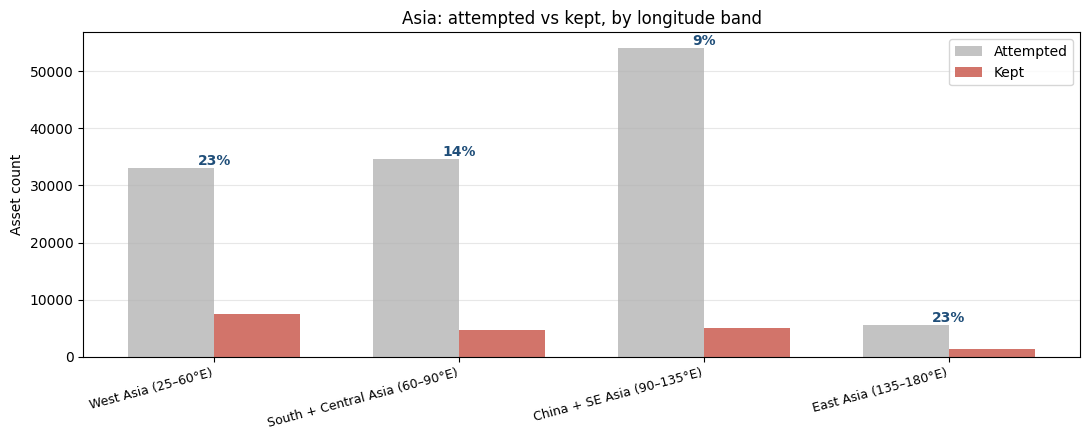

In [19]:
# longitude breakdown of Asia failures vs. attempts.
asia_att    = attempted_all[attempted_all["region"] == "asia"]
asia_failed = failed_all[failed_all["region"] == "asia"]

LON_BINS = [
    ("West Asia (25–60°E)",        25,  60),
    ("South + Central Asia (60–90°E)", 60,  90),
    ("China + SE Asia (90–135°E)", 90,  135),
    ("East Asia (135–180°E)",      135, 180),
]

rows = []
for label, lo, hi in LON_BINS:
    att_n  = ((asia_att["lon"]    >= lo) & (asia_att["lon"]    < hi)).sum()
    fail_n = ((asia_failed["lon"] >= lo) & (asia_failed["lon"] < hi)).sum()
    yield_n = att_n - fail_n
    rows.append({
        "band":      label,
        "attempted": att_n,
        "kept":      yield_n,
        "failed":    fail_n,
        "yield_pct": yield_n / att_n * 100 if att_n else float("nan"),
        "fail_pct":  fail_n  / att_n * 100 if att_n else float("nan"),
    })
asia_lon_df = pd.DataFrame(rows)
print(asia_lon_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(asia_lon_df))
width = 0.35
ax.bar(x - width/2, asia_lon_df["attempted"], width,
       color="#888888", alpha=0.5, label="Attempted")
ax.bar(x + width/2, asia_lon_df["kept"], width,
       color="#c0392b", alpha=0.7, label="Kept")
ax.set_xticks(x)
ax.set_xticklabels(asia_lon_df["band"], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Asset count")
ax.set_title("Asia: attempted vs kept, by longitude band")
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="y")

# yield % annotations on top
for i, r in asia_lon_df.iterrows():
    if not np.isnan(r["yield_pct"]):
        ax.annotate(f"{r['yield_pct']:.0f}%",
                    (i, max(r["attempted"], r["kept"])),
                    ha="center", va="bottom", fontsize=10, fontweight="bold",
                    color="#1f4e79")
plt.tight_layout()
plt.show()


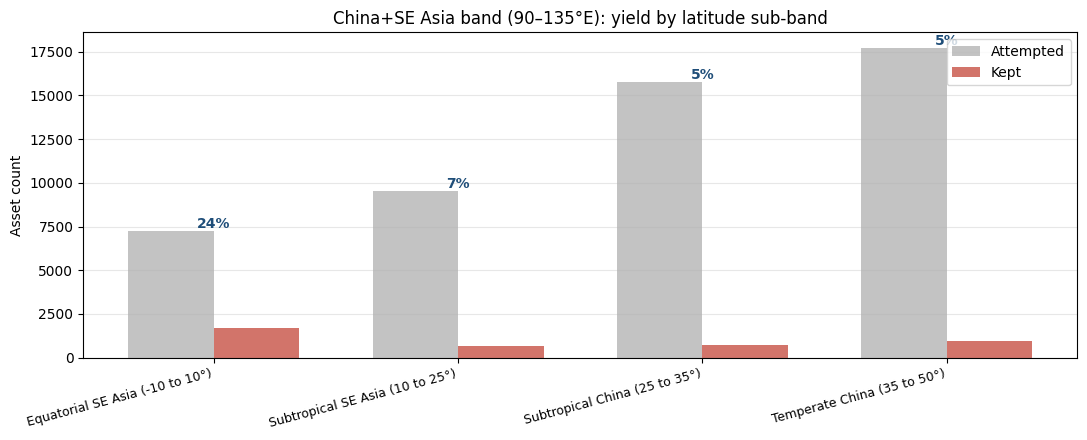

In [20]:
# latitude split inside the China+SE Asia longitude band
band_lo, band_hi = 90, 135
asia_band_att    = asia_att[(asia_att["lon"] >= band_lo) & (asia_att["lon"] < band_hi)]
asia_band_failed = asia_failed[(asia_failed["lon"] >= band_lo) & (asia_failed["lon"] < band_hi)]

LAT_SUBBANDS = [
    ("Equatorial SE Asia (-10 to 10°)",  -10, 10),
    ("Subtropical SE Asia (10 to 25°)",   10, 25),
    ("Subtropical China (25 to 35°)",     25, 35),
    ("Temperate China (35 to 50°)",       35, 50),
]
rows = []
for label, lo, hi in LAT_SUBBANDS:
    att_n  = ((asia_band_att["lat"]    >= lo) & (asia_band_att["lat"]    < hi)).sum()
    fail_n = ((asia_band_failed["lat"] >= lo) & (asia_band_failed["lat"] < hi)).sum()
    kept_n = att_n - fail_n
    rows.append({
        "sub_band":  label,
        "attempted": att_n,
        "kept":      kept_n,
        "failed":    fail_n,
        "yield_pct": kept_n / att_n * 100 if att_n else float("nan"),
    })
asia_band_lat_df = pd.DataFrame(rows)
print(asia_band_lat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(asia_band_lat_df))
width = 0.35
ax.bar(x - width/2, asia_band_lat_df["attempted"], width,
       color="#888888", alpha=0.5, label="Attempted")
ax.bar(x + width/2, asia_band_lat_df["kept"], width,
       color="#c0392b", alpha=0.7, label="Kept")
ax.set_xticks(x)
ax.set_xticklabels(asia_band_lat_df["sub_band"], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Asset count")
ax.set_title(f"China+SE Asia band ({band_lo}–{band_hi}°E): yield by latitude sub-band")
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="y")
for i, r in asia_band_lat_df.iterrows():
    if not np.isnan(r["yield_pct"]):
        ax.annotate(f"{r['yield_pct']:.0f}%",
                    (i, max(r["attempted"], r["kept"])),
                    ha="center", va="bottom", fontsize=10, fontweight="bold",
                    color="#1f4e79")
plt.tight_layout()
plt.show()

**Interpretation guide for the longitude breakdown:**

- **Yield is uniformly low across all longitude bands (10–15%):** the issue
  isn't Chinese STAC catalog gaps or any specific sub-region; the entire Asia
  fetch was undermined. Most likely cause given project context: the home-wifi
  re-fetch wasn't fully redone on campus, and the Asia checkpoint reflects a
  partial run.
- **One band is dramatically worse (e.g. China 90–135°E at <5%, others at
  40%+):** STAC catalog availability issue specific to that region's imagery.
  Worth filing as a known limitation, but not a project-wide fetch problem.
- **Yields look reasonable (40–60%) in some bands but the global yield was 38.6%:**
  the global denominator is being dragged down by a different region entirely
  — re-check the per-region table from the setup cell.


### Interpreting Check 3

- **Failures cluster in equatorial bands and the geographic-yield map's red
  zones:** cloud-driven. Consistent with the headline framing in Check 1's
  interpretation.

- **Failures are scattered uniformly with no spatial pattern:** points to
  network, API, or fetcher issues rather than the imagery itself. Look at run
  logs and checkpoints.

- **Failures cluster in one specific region (e.g. asia) but not others:**
  region-specific cause. Likely a bad fetch run rather than a fundamental
  geographic bias. Worth re-running that region.

- **Failures cluster near coastlines or water bodies:** Sentinel-2 scene-edge
  artifacts or windowed reads landing on the ocean. Worth tightening QC.

To diagnose individually: open `qa_outputs/failed_tiles_sample_for_inspection.csv`
and click the `pc_explorer_url` for a few rows. If Planetary Computer shows
recent low-cloud Sentinel-2 imagery at that exact lat/lon and the fetch still
failed, that's a fetcher bug worth chasing. If the only available scenes are
cloudy or there are no scenes in the date range, the failure is environmental.


## Suggested manuscript paragraph (revised)

The original draft of this paragraph blamed cloud cover for the Asia yield.
The diagnostics in this notebook don't support that — Asia's yield is flat-low
across all latitude bands, including temperate ones where neighboring North
America hits >90%. The honest version separates the global cloud-cover signal
(real, modest, visible in tropical Africa and South America) from the
Asia-specific underperformance (real, large, not cloud-driven).

> "Across all seven continental extracts, n=213,577 attempted assets after
> deduplication yielded 82,522 final tiles (38.6% overall yield). Yield varies
> substantially by region: North America (NN%), Europe (NN%), and the Americas
> (NN–NN%) achieved yields broadly consistent with Sentinel-2 scene
> availability and our 20% cloud-cover threshold, with a modest reduction in
> tropical bands (0–20° absolute latitude) in Africa (~55%) and South America
> (~60%) consistent with cloud climatology. The Asia extract underperformed
> the other continents substantially (NN% yield), and per-latitude
> decomposition shows this is not a cloud-cover effect — yield is flat across
> all Asian latitudes, including temperate bands above 35°N where neighboring
> regions exceed 90%. We attribute the Asia shortfall to [STAC catalog
> availability in the X band / an incomplete fetch run that has since been
> rerun on campus network / etc. — fill in after running the diagnostic
> cells above]. Visual inspection of n=30 randomly sampled tiles stratified
> across regions confirmed image quality consistent with substation
> infrastructure; mean pixel values and valid-pixel ratios fell well inside QC
> tolerances. We release the coordinates of all NN,NNN unrecovered assets
> alongside the dataset so future work can substitute alternative imagery
> sources."

Notes for filling in numbers:
- Per-region yields are in `region_stats` from the setup cell.
- The Asia-specific cause depends on what the longitude decomposition above
  showed. If it's a uniform shortfall, the home-wifi/campus-rerun story is
  the most likely one. If it's concentrated in one longitude band, name the
  band and treat it as a STAC availability limitation.
- If you re-run Asia on campus and the shortfall closes, this paragraph
  collapses substantially — most of it becomes "minor cloud-cover bias in
  tropical bands, no other systematic issues."
